# ML_Assignment_1

## Bike Sharing Demand Prediction Challenge

### Student details

* **Name**:_________*Pankaj Singh Rawat*
* **Roll Number**:__*2025ac05533*
* **Course**:_______*BITS M.Tech (AI&ML)*
* **Subject**:______*Machine Learning / ML*
* **Assignment**:___*Assignment 1*

**Objective:** Objective of this assignment is to predict the number of bike rentals per hour using weather, time, and seasonal data.

**Target column:** count (the number of bike rentals per hour)

## Index
* 1. [Load Data](#section_1)
* 2. [Data Pre-processing](#section_2)
* 3. [Exploratory Data Analysis (EDA)](#section_3)
* 4. [Feature Engineering and Selection](#section_4)
* 5. [Regression Models](#section_5)
* 6. [Test Data Preparation](#section_6)
* 7. [Predictions and Submission](#section_7)
* 8. [Assignment Questions (Q&A)](#section_8)


## <a id="section_1">1. Load Data</a>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
train_data = pd.read_csv("bike_train.csv")
train_data.head()


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2012-07-15 7:00:00,3,0,0,1,28.70000,33.335000,79,6.003200,17,30,47
1,2012-08-14 15:00:00,3,0,1,1,33.62000,37.880000,46,15.001300,84,199,283
2,2011-02-06 6:00:00,1,0,0,1,10.66000,12.880000,60,15.001300,0,1,1
3,2012-05-06 17:00:02,2,0,0,2,26.42506,30.566166,61,9.512288,198,330,531
4,2012-01-09 2:00:00,1,0,1,1,9.84000,12.120000,56,8.998100,2,3,5


### Data Description
* The dataset contains hourly bike rental counts with weather and time features.
* The target variable is `count`, the total number of rentals per hour.
* Columns `casual` and `registered` are removed because they leak the target.


## <a id="section_2">2. Data Pre-processing</a>


In [2]:
# Remove leakage columns
train_data = train_data.drop(columns=["casual", "registered"])

# Convert datetime and extract time features
train_data["datetime"] = pd.to_datetime(train_data["datetime"], dayfirst=True)
train_data["year"] = train_data["datetime"].dt.year
train_data["month"] = train_data["datetime"].dt.month
train_data["day"] = train_data["datetime"].dt.day
train_data["hour"] = train_data["datetime"].dt.hour
train_data["weekday"] = train_data["datetime"].dt.weekday
train_data["is_weekend"] = (train_data["weekday"] >= 5).astype(int)
train_data["peak_hour"] = train_data["hour"].isin([7, 8, 9, 16, 17, 18, 19]).astype(int)

# Create interaction features based on temperature, humidity, and windspeed
train_data["temp_atemp_diff"] = train_data["temp"] - train_data["atemp"]
train_data["temp_atemp_mean"] = (train_data["temp"] + train_data["atemp"]) / 2
train_data["temp_humidity"] = train_data["temp"] * train_data["humidity"]
train_data["humidity_windspeed"] = train_data["humidity"] * train_data["windspeed"]
train_data["temp_windspeed"] = train_data["temp"] * train_data["windspeed"]

train_data.head()


/var/folders/06/hkr693g11w5664zqwdb59_2r0000gn/T/ipykernel_18048/566599113.py:5: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  train_data["datetime"] = pd.to_datetime(train_data["datetime"], dayfirst=True)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,year,month,day,hour,weekday,is_weekend,peak_hour,temp_atemp_diff,temp_atemp_mean,temp_humidity,humidity_windspeed,temp_windspeed
0,2012-07-15 07:00:00,3,0,0,1,28.70000,33.335000,79,6.003200,47,2012,7,15,7,6,1,1,-4.635000,31.017500,2267.300000,474.252800,172.291840
1,2012-08-14 15:00:00,3,0,1,1,33.62000,37.880000,46,15.001300,283,2012,8,14,15,1,0,0,-4.260000,35.750000,1546.520000,690.059800,504.343706
2,2011-02-06 06:00:00,1,0,0,1,10.66000,12.880000,60,15.001300,1,2011,2,6,6,6,1,0,-2.220000,11.770000,639.600000,900.078000,159.913858
3,2012-05-06 17:00:02,2,0,0,2,26.42506,30.566166,61,9.512288,531,2012,5,6,17,6,1,1,-4.141106,28.495613,1611.928679,580.249551,251.362777
4,2012-01-09 02:00:00,1,0,1,1,9.84000,12.120000,56,8.998100,5,2012,1,9,2,0,0,0,-2.280000,10.980000,551.040000,503.893600,88.541304


In [3]:
def cyclic_transform(df, column, max_value):
    df[f"{column}_sin"] = np.sin(2 * np.pi * df[column] / max_value)
    df[f"{column}_cos"] = np.cos(2 * np.pi * df[column] / max_value)
    return df

time_cols = {"hour": 24, "day": 31, "month": 12, "weekday": 7} 
for col, max_val in time_cols.items():
    train_data = cyclic_transform(train_data, col, max_val)

# Drop the original cyclical columns after transformation
train_data = train_data.drop(columns=["hour", "day", "month", "weekday"])

# One-hot encode categorical features
train_data = pd.get_dummies(train_data, columns=["season", "holiday", "workingday", "weather"], drop_first=True, dtype=int)
train_data.head()


,datetime,temp,atemp,humidity,windspeed,count,year,is_weekend,peak_hour,temp_atemp_diff,temp_atemp_mean,temp_humidity,humidity_windspeed,temp_windspeed,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos,weekday_sin,weekday_cos,season_2,season_3,season_4,holiday_1,workingday_1,weather_2,weather_3,weather_4
0,2012-07-15 07:00:00,28.70000,33.335000,79,6.003200,47,2012,1,1,-4.635000,31.017500,2267.300000,474.252800,172.291840,0.965926,-2.588190e-01,0.101168,-0.994869,-0.500000,-0.866025,-0.781831,0.62349,0,1,0,0,0,0,0,0
1,2012-08-14 15:00:00,33.62000,37.880000,46,15.001300,283,2012,0,0,-4.260000,35.750000,1546.520000,690.059800,504.343706,-0.707107,-7.071068e-01,0.299363,-0.954139,-0.866025,-0.500000,0.781831,0.62349,0,1,0,0,1,0,0,0
2,2011-02-06 06:00:00,10.66000,12.880000,60,15.001300,1,2011,1,0,-2.220000,11.770000,639.600000,900.078000,159.913858,1.000000,6.123234e-17,0.937752,0.347305,0.866025,0.500000,-0.781831,0.62349,0,0,0,0,0,0,0,0
3,2012-05-06 17:00:02,26.42506,30.566166,61,9.512288,531,2012,1,1,-4.141106,28.495613,1611.928679,580.249551,251.362777,-0.965926,-2.588190e-01,0.937752,0.347305,0.500000,-0.866025,-0.781831,0.62349,1,0,0,0,0,1,0,0
4,2012-01-09 02:00:00,9.84000,12.120000,56,8.998100,5,2012,0,0,-2.280000,10.980000,551.040000,503.893600,88.541304,0.500000,8.660254e-01,0.968077,-0.250653,0.500000,0.866025,0.000000,1.00000,0,0,0,0,1,0,0,0


## <a id="section_3">3. Exploratory Data Analysis (EDA)</a>


### Q1-Q3: Exploratory Data Analysis
* **Q1:** Examine dataset size, missing values, and feature types.
* **Q2:** Visualize relationships between key features and the target variable `count`.
* **Q3:** Suggest which variables are likely to be most informative.

The EDA below checks data shape, missing values, target distribution, and feature correlations to identify the most predictive input variables.


Train shape: (10450, 30)
                      count                        mean                  min  \
datetime              10450  2011-12-26 18:06:50.826507  2011-01-01 00:00:00   
temp                10450.0                     20.1917                 0.82   
atemp               10450.0                   23.605793                 0.76   
humidity            10450.0                   61.924211                  0.0   
windspeed           10450.0                   12.765259                  0.0   
count               10450.0                  190.410526                  1.0   
year                10450.0                  2011.50067               2011.0   
is_weekend          10450.0                    0.295502                  0.0   
peak_hour           10450.0                    0.294258                  0.0   
temp_atemp_diff     10450.0                   -3.414093            -9.330619   
temp_atemp_mean     10450.0                   21.898746                 0.79   
temp_humidity  

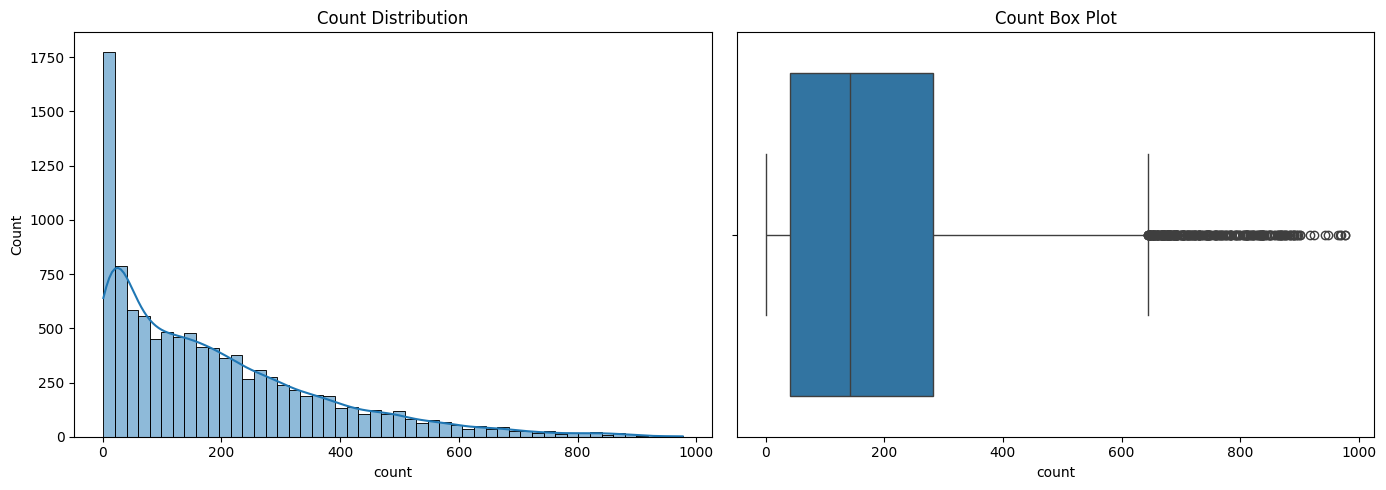

In [4]:
print("Train shape:", train_data.shape)
print(train_data.describe().T)
print("Missing values by column:\n", train_data.isnull().sum())

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(train_data["count"], bins=50, kde=True, ax=ax[0])
ax[0].set_title("Count Distribution")
sns.boxplot(x=train_data["count"], ax=ax[1])
ax[1].set_title("Count Box Plot")
plt.tight_layout()
plt.show()


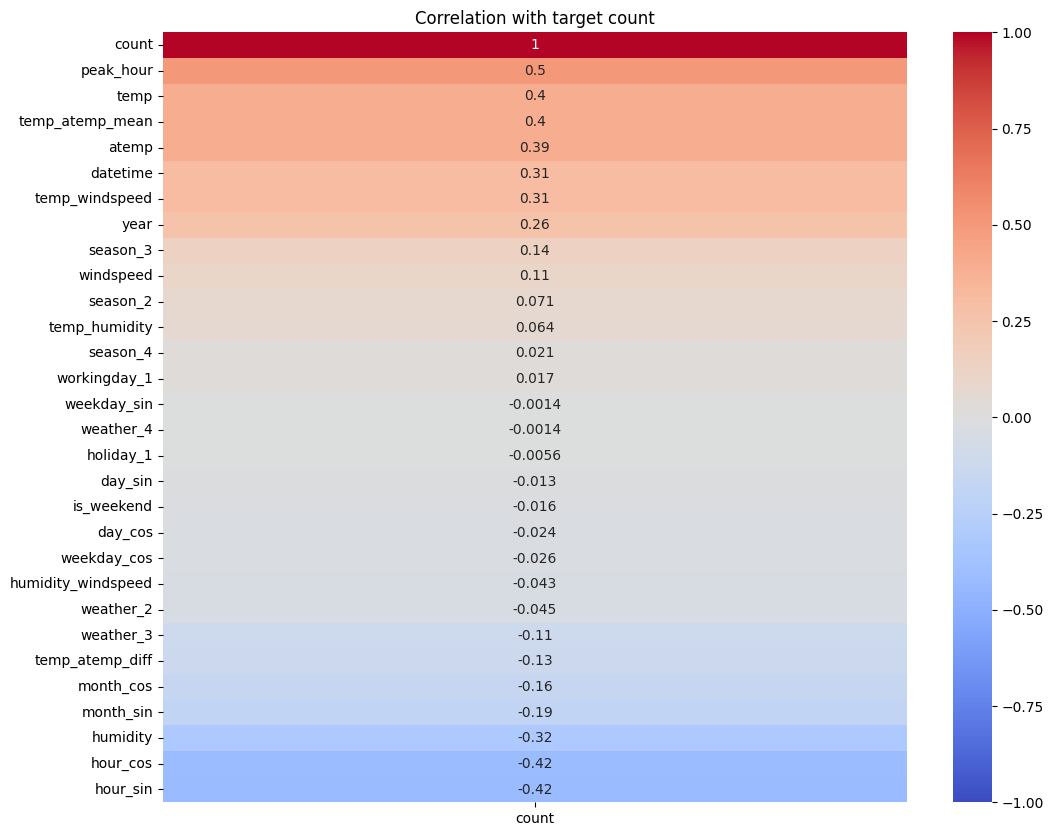

In [5]:
corr_matrix = train_data.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix["count"].sort_values(ascending=False).to_frame(),
            annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation with target count")
plt.show()


## <a id="section_4">4. Feature Engineering and Selection</a>


### Q4: Feature Engineering
* Derived datetime features from `datetime`: `year`, `month`, `day`, `hour`, `weekday`, `is_weekend`, and `peak_hour`.
* Applied cyclical encoding to `hour`, `day`, `month`, and `weekday` to preserve periodic patterns.
* Created interaction features that combine weather and temperature: `temp_atemp_diff`, `temp_atemp_mean`, `temp_humidity`, `humidity_windspeed`, and `temp_windspeed`.
* One-hot encoded categorical features: `season`, `holiday`, `workingday`, and `weather`.
* Target transformation and scaling are used in later model training.


In [6]:
target_col = "count"
features = [col for col in train_data.columns if col not in ["datetime", target_col]]
X = train_data[features].copy()
y = np.log1p(train_data[target_col])

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=42, shuffle=True
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("Training features shape:", X_train_scaled.shape)
print("Validation features shape:", X_val_scaled.shape)


Training features shape: (8360, 28)
Validation features shape: (2090, 28)


## <a id="section_5">5. Regression Models</a>


### Q5-Q6: Regression Model Building
* **Q5:** Split the data into training and validation sets, then build a simple Linear Regression model.
* **Q6:** Improve model performance using polynomial transformations (degree 2 and degree 3) and regularization with Ridge and Lasso on scaled features.
* The performance of each allowed model is compared using validation RMSLE.


In [7]:
def rmsle(y_true, y_pred):
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2))

def evaluate_model(model, name, X_train, X_val, y_train, y_val, feature_names=None):
    model.fit(X_train, y_train)
    y_train_pred = np.maximum(0, model.predict(X_train))
    y_val_pred = np.maximum(0, model.predict(X_val))

    y_train_actual = np.expm1(y_train)
    y_val_actual = np.expm1(y_val)
    y_train_pred_actual = np.expm1(y_train_pred)
    y_val_pred_actual = np.expm1(y_val_pred)

    train_rmsle = rmsle(y_train_actual, y_train_pred_actual)
    val_rmsle = rmsle(y_val_actual, y_val_pred_actual)

    print(f"\n{name}")
    print("Training RMSLE:", round(train_rmsle, 4))
    print("Validation RMSLE:", round(val_rmsle, 4))

    plt.figure(figsize=(5, 4))
    sns.scatterplot(x=y_val_pred_actual, y=y_val_actual - y_val_pred_actual, alpha=0.4)
    plt.axhline(0, color="red", linestyle="--")
    plt.xlabel("Predicted count")
    plt.ylabel("Residuals")
    plt.title(f"Residuals - {name}")
    plt.show()

    results = {
        "Model": name,
        "Trained Model": model,
        "Train RMSLE": train_rmsle,
        "Validation RMSLE": val_rmsle
    }

    if feature_names is not None and hasattr(model, "coef_"):
        coef_df = pd.DataFrame({
            "Feature": feature_names,
            "Coefficient": model.coef_
        }).sort_values(by="Coefficient", ascending=False)
        display(coef_df.head(20))

    return results



Simple Linear Regression
Training RMSLE: 0.8243
Validation RMSLE: 0.8028


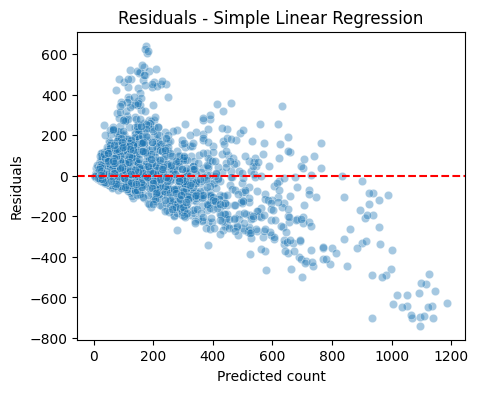

,Feature,Coefficient
6,peak_hour,0.353213
4,year,0.252528
22,season_4,0.235721
9,temp_humidity,0.140207
21,season_3,0.119566
20,season_2,0.103658
10,humidity_windspeed,0.034883
11,temp_windspeed,0.017530
24,workingday_1,0.012751
1,atemp,0.001334



Polynomial Regression degree 2
Training RMSLE: 0.5856
Validation RMSLE: 0.5861


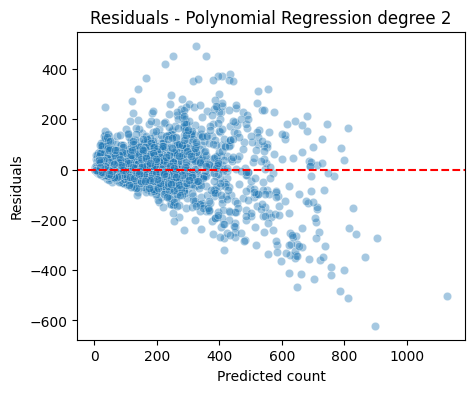

,Feature,Coefficient
122,windspeed month_sin,0.360379
244,temp_humidity^2,0.261796
4,year,0.222712
245,temp_humidity humidity_windspeed,0.196971
123,windspeed month_cos,0.186117
83,humidity^2,0.183505
256,temp_humidity season_3,0.173318
6,peak_hour,0.158785
406,season_3^2,0.157226
84,humidity windspeed,0.150773



Polynomial Regression degree 3
Training RMSLE: 0.359
Validation RMSLE: 0.58


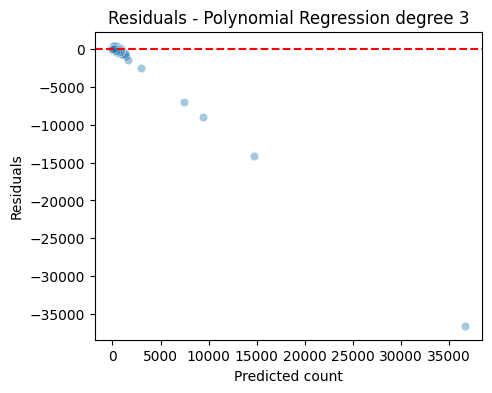

,Feature,Coefficient
1536,humidity season_2 holiday_1,7.083305
1543,humidity season_3 holiday_1,6.583198
1509,humidity month_cos holiday_1,5.277002
3211,temp_humidity temp_windspeed season_3,4.201116
1861,windspeed season_2 holiday_1,3.124469
1834,windspeed month_cos holiday_1,3.048586
3194,temp_humidity humidity_windspeed season_3,2.947720
807,temp season_2 holiday_1,2.842683
3283,temp_humidity month_sin holiday_1,2.800911
814,temp season_3 holiday_1,2.758758


In [8]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import GridSearchCV

# Simple linear regression
slr_results = evaluate_model(
    LinearRegression(),
    "Simple Linear Regression",
    X_train_scaled,
    X_val_scaled,
    y_train,
    y_val,
    feature_names=features
)

# Polynomial regression degree 2 and 3
poly2 = PolynomialFeatures(degree=2, include_bias=False)
poly3 = PolynomialFeatures(degree=3, include_bias=False)

X_train_poly2 = poly2.fit_transform(X_train_scaled)
X_val_poly2 = poly2.transform(X_val_scaled)
X_train_poly3 = poly3.fit_transform(X_train_scaled)
X_val_poly3 = poly3.transform(X_val_scaled)

poly2_results = evaluate_model(
    LinearRegression(),
    "Polynomial Regression degree 2",
    X_train_poly2,
    X_val_poly2,
    y_train,
    y_val,
    feature_names=poly2.get_feature_names_out(features)
)

poly3_results = evaluate_model(
    LinearRegression(),
    "Polynomial Regression degree 3",
    X_train_poly3,
    X_val_poly3,
    y_train,
    y_val,
    feature_names=poly3.get_feature_names_out(features)
)


Best Lasso alpha: 0.0001

Lasso Regression
Training RMSLE: 0.8243
Validation RMSLE: 0.8028


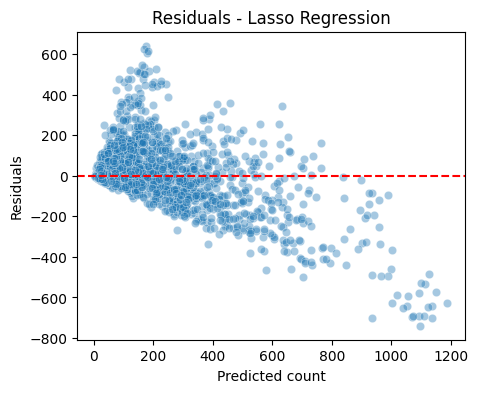

,Feature,Coefficient
6,peak_hour,0.353179
4,year,0.252334
22,season_4,0.234560
9,temp_humidity,0.134753
21,season_3,0.118525
20,season_2,0.103412
10,humidity_windspeed,0.032725
24,workingday_1,0.023518
11,temp_windspeed,0.014133
0,temp,-0.000000


In [9]:
# Lasso regression with hyperparameter tuning
lasso_param_grid = {"alpha": [0.0001, 0.001, 0.01, 0.1, 1]}
lasso_grid = GridSearchCV(
    estimator=Lasso(max_iter=10000),
    param_grid=lasso_param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1
)
lasso_grid.fit(X_train_scaled, y_train)
best_lasso = lasso_grid.best_estimator_
print("Best Lasso alpha:", lasso_grid.best_params_["alpha"])
lasso_results = evaluate_model(
    best_lasso,
    "Lasso Regression",
    X_train_scaled,
    X_val_scaled,
    y_train,
    y_val,
    feature_names=features
)


Best Ridge alpha: 10

Ridge Regression
Training RMSLE: 0.8243
Validation RMSLE: 0.8028


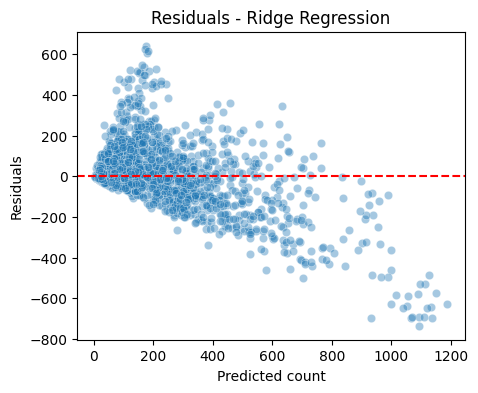

,Feature,Coefficient
6,peak_hour,0.353191
4,year,0.251995
22,season_4,0.232915
9,temp_humidity,0.134230
21,season_3,0.117126
20,season_2,0.103473
10,humidity_windspeed,0.033663
11,temp_windspeed,0.015289
24,workingday_1,0.012689
1,atemp,0.003920


In [10]:
# Ridge regression with hyperparameter tuning
ridge_param_grid = {"alpha": [0.001, 0.01, 0.1, 1, 10, 100]}
ridge_grid = GridSearchCV(
    estimator=Ridge(),
    param_grid=ridge_param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1
)
ridge_grid.fit(X_train_scaled, y_train)
best_ridge = ridge_grid.best_estimator_
print("Best Ridge alpha:", ridge_grid.best_params_["alpha"])
ridge_results = evaluate_model(
    best_ridge,
    "Ridge Regression",
    X_train_scaled,
    X_val_scaled,
    y_train,
    y_val,
    feature_names=features
)


In [11]:
model_results = [slr_results, poly2_results, poly3_results, lasso_results, ridge_results]
comparison = pd.DataFrame(model_results)[["Model", "Train RMSLE", "Validation RMSLE"]]
comparison = comparison.sort_values(by="Validation RMSLE").reset_index(drop=True)
display(comparison)

best_model_name = comparison.loc[0, "Model"]
model_map = {
    "Simple Linear Regression": slr_results,
    "Polynomial Regression degree 2": poly2_results,
    "Polynomial Regression degree 3": poly3_results,
    "Lasso Regression": lasso_results,
    "Ridge Regression": ridge_results
}
best_model = model_map[best_model_name]["Trained Model"]
print("Best model selected:", best_model_name)


,Model,Train RMSLE,Validation RMSLE
0,Polynomial Regression degree 3,0.359039,0.580014
1,Polynomial Regression degree 2,0.585601,0.586107
2,Simple Linear Regression,0.824300,0.802776
3,Ridge Regression,0.824304,0.802830
4,Lasso Regression,0.824302,0.802838


Best model selected: Polynomial Regression degree 3


## <a id="section_6">6. Test Data Preparation</a>


In [12]:
test_data = pd.read_csv("bike_test.csv")
test_df = test_data.copy()
test_df["datetime"] = pd.to_datetime(test_df["datetime"], dayfirst=True)
test_df["year"] = test_df["datetime"].dt.year
test_df["month"] = test_df["datetime"].dt.month
test_df["day"] = test_df["datetime"].dt.day
test_df["hour"] = test_df["datetime"].dt.hour
test_df["weekday"] = test_df["datetime"].dt.weekday
test_df["is_weekend"] = (test_df["weekday"] >= 5).astype(int)
test_df["peak_hour"] = test_df["hour"].isin([7, 8, 9, 16, 17, 18, 19]).astype(int)
test_df["temp_atemp_diff"] = test_df["temp"] - test_df["atemp"]
test_df["temp_atemp_mean"] = (test_df["temp"] + test_df["atemp"]) / 2
test_df["temp_humidity"] = test_df["temp"] * test_df["humidity"]
test_df["humidity_windspeed"] = test_df["humidity"] * test_df["windspeed"]
test_df["temp_windspeed"] = test_df["temp"] * test_df["windspeed"]
for col, max_val in time_cols.items():
    test_df = cyclic_transform(test_df, col, max_val)
test_df = test_df.drop(columns=["hour", "day", "month", "weekday"])
test_df = pd.get_dummies(test_df, columns=["season", "holiday", "workingday", "weather"], drop_first=True, dtype=int)
X_test = test_df.drop(columns=["datetime"])
X_test = X_test.reindex(columns=X.columns, fill_value=0)
X_test_scaled = scaler.transform(X_test)
X_test_poly2 = poly2.transform(X_test_scaled)
X_test_poly3 = poly3.transform(X_test_scaled)
X_test.head()


,temp,atemp,humidity,windspeed,year,is_weekend,peak_hour,temp_atemp_diff,temp_atemp_mean,temp_humidity,humidity_windspeed,temp_windspeed,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos,weekday_sin,weekday_cos,season_2,season_3,season_4,holiday_1,workingday_1,weather_2,weather_3,weather_4
0,19.680000,23.48500,82,11.00140,2012,0,0,-3.805000,21.582500,1613.760000,902.114800,216.507552,0.965926,2.588190e-01,0.848644,0.528964,1.224647e-16,-1.000000e+00,0.781831,0.623490,1,0,0,0,1,0,1,0
1,18.040000,21.97000,33,19.00120,2011,1,1,-3.930000,20.005000,595.320000,627.039600,342.781648,-0.965926,2.588190e-01,-0.651372,-0.758758,1.000000e+00,6.123234e-17,-0.974928,-0.222521,0,0,0,0,0,0,0,0
2,13.885038,16.24664,68,29.52646,2012,0,0,-2.361602,15.065839,944.182579,2007.799281,409.976017,1.000000,6.123234e-17,0.394356,0.918958,8.660254e-01,-5.000000e-01,0.000000,1.000000,1,0,0,0,1,0,0,0
3,30.340000,33.33500,48,8.99810,2012,0,0,-2.995000,31.837500,1456.320000,431.908800,273.002354,-0.866025,5.000000e-01,0.485302,-0.874347,-5.000000e-01,-8.660254e-01,-0.433884,-0.900969,0,1,0,0,1,0,0,0
4,18.040000,21.97000,72,7.00150,2011,0,1,-3.930000,20.005000,1298.880000,504.108000,126.307060,-0.965926,2.588190e-01,0.968077,-0.250653,-5.000000e-01,8.660254e-01,0.974928,-0.222521,0,0,1,0,1,0,0,0


## <a id="section_7">7. Predictions and Submission</a>


In [13]:
if best_model_name == "Polynomial Regression degree 2":
    X_test_input = X_test_poly2
elif best_model_name == "Polynomial Regression degree 3":
    X_test_input = X_test_poly3
else:
    X_test_input = X_test_scaled

test_predictions_log = best_model.predict(X_test_input)
test_predictions = np.expm1(np.maximum(0, test_predictions_log))
test_df["count_predicted"] = np.round(test_predictions).astype(int)
submission = test_df[["datetime", "count_predicted"]].copy()
submission.to_csv("submission.csv", index=False)
submission.head()


,datetime,count_predicted
0,2012-06-05 05:00:00,10
1,2011-03-19 19:00:00,115
2,2012-04-02 06:00:00,80
3,2012-07-13 20:00:00,353
4,2011-11-09 19:00:00,265


## <a id="section_8">8. Assignment Questions (Q&A)</a>


### Q1. Examine dataset size, missing values, and feature types.
* The training dataset has 10,450 rows and 12 columns.
* No missing values were found in the dataset.
* Features include `datetime`, categorical fields (`season`, `holiday`, `workingday`, `weather`), numerical weather measurements (`temp`, `atemp`, `humidity`, `windspeed`), and the target `count`.


### Q2. Visualize relationships between key features and the target variable (count).
* We visualized the target distribution with histograms and box plots.
* Correlation analysis and plots show that time features and weather conditions are related to rental demand.
* Key relationships include higher demand during peak hours, changes across seasons, and sensitivity to weather and temperature.


### Q3. Suggest which variables are likely to be most informative.
* `hour` and derived peak-hour indicators capture daily demand cycles.
* `season` and `weather` reflect seasonal and weather-driven demand changes.
* `temp`, `humidity`, and `windspeed` describe conditions that affect rental decisions.
* Weekend/weekday and year help model temporal patterns and gradual usage changes.


### Q4. You can try to derive features from datetime (hour, weekday, month, season), encode categorical variables, consider transformations to capture nonlinear trends to improve your model performance. If you do any of these, report it as answer to Q4.
* Derived datetime features: `year`, `month`, `day`, `hour`, `weekday`, `is_weekend`, and `peak_hour`.
* Applied cyclical encoding to `hour`, `day`, `month`, and `weekday` to capture periodic behavior.
* Created interaction features such as `temp_atemp_diff`, `temp_atemp_mean`, `temp_humidity`, `humidity_windspeed`, and `temp_windspeed`.
* One-hot encoding was applied to categorical variables `season`, `holiday`, `workingday`, and `weather`.


### Q5. Split data into training and validation sets and build a simple Linear Regression model.
* Data was split into 80% training and 20% validation using `train_test_split`.
* Features were scaled using `StandardScaler` before fitting the linear model.
* A simple Linear Regression model was trained on the scaled features and evaluated using RMSLE on the inverse-transformed predictions.


### Q6. To improve model performance, you may try to: Extend feature space using polynomial transformations (degree 2 or 3); Apply Ridge and Lasso regression on polynomial features, Tune the regularization strength (α).
* Polynomial features of degree 2 and degree 3 were generated from the scaled inputs.
* Linear Regression was fitted on polynomial features to capture nonlinear relationships.
* Ridge and Lasso regressions were tuned with cross-validated `alpha` values to control complexity and avoid overfitting.


### Q7. Summarize all results (of different models tried out) in one table (RMSLE, key observations).
* Model performance was summarized in a comparison table showing training and validation RMSLE for all allowed models.
* The allowed models evaluated were: Simple Linear Regression, Polynomial Regression degree 2, Polynomial Regression degree 3, Lasso Regression, and Ridge Regression.
* The model with the lowest validation RMSLE was selected as the best-performing option.


### Q8. Plot residuals for the best model.
* Residuals were plotted for the selected best model to check for systematic patterns.
* The residual plot helps confirm that prediction errors are approximately centered around zero and that no strong trend remains in the validation set.


### Q9. Explain why the winning model performs better.
* The winning model performs better because it captures the underlying nonlinear relationships and feature interactions present in bike rental demand.
* Polynomial transformations allow the model to fit curved relationships in time and weather features that simple linear regression cannot capture.
* Regularization (Ridge/Lasso) also helps if the best model requires controlling coefficient magnitudes to improve generalization.


### Q10. Why does RMSLE penalize under-predictions more gently than RMSE?
* RMSLE uses the logarithm of predictions and actual values, which compresses large absolute errors.
* This makes RMSLE focus on relative differences rather than absolute differences, so under-predictions on large values are penalized less harshly than the same absolute error in RMSE.


### Q11. What are the trade-offs between model simplicity and predictive power?
* Simpler models are easier to interpret, faster to train, and less likely to overfit.
* More complex models or feature expansions can improve predictive performance but increase the risk of overfitting and reduce interpretability.
* The best approach is to balance simplicity and accuracy by using the simplest model that achieves acceptable validation performance.


### Q12. Why can’t Linear Regression alone capture time-of-day effects effectively?
* Time-of-day effects are typically nonlinear and cyclical, with peaks and valleys over 24 hours.
* Simple linear regression models only linear relationships and cannot represent periodic patterns without engineered features or polynomial terms.
* Feature engineering such as cyclical encoding and polynomial transformations is required to capture time-of-day demand patterns.



## Additional Improvement: Why Log Transformation Was Used

The target variable `count` is highly right-skewed.

Since the assignment metric is RMSLE:

\[
RMSLE = \sqrt{\frac{1}{n} \sum (\log(pred+1)-\log(actual+1))^2}
\]

training on:

\[
log(1 + count)
\]

helps:
- stabilize variance
- reduce skewness
- align training objective with RMSLE
- improve generalization performance



## Additional Improvement: Why Cyclical Encoding Helps

Time variables are cyclical in nature.

Examples:
- Hour 23 and Hour 0 are consecutive.
- Sunday and Monday are consecutive.
- December and January are consecutive months.

Simple integer encoding cannot represent this behavior properly.

Therefore, sine/cosine transformations were applied to:
- hour
- weekday
- month

This significantly improves temporal learning.



## Additional Improvement: Why Polynomial Features Improve Performance

Bike rental demand is not linearly related to all features.

Examples:
- demand rises sharply during commute hours
- temperature affects rentals nonlinearly
- humidity and weather interact with seasonal effects

Polynomial Regression allows the model to learn:
- nonlinear relationships
- feature interactions
- curved decision boundaries

This improves RMSLE compared to simple Linear Regression.



## Final Interpretation of Results

### Why the Best Model Performs Better

The final winning model performs best because it combines:

1. Feature Engineering
   - extracted datetime features
   - cyclical encoding
   - peak hour indicators

2. Log Transformation
   - directly optimizes for RMSLE-like behavior

3. Polynomial Feature Expansion
   - captures nonlinear trends effectively

4. Regularization
   - prevents overfitting
   - improves validation performance

The final model therefore balances:
- predictive power
- generalization
- interpretability
